# XRD Batch Analysis to Technical Memo
### Characterization Pipeline · samdhole.github.io

---

## A Researcher's 4-Hour Task â†’ ~90 Seconds of Computation

**Without this pipeline:**

A materials scientist receives 8 XRD diffraction patterns from a measurement campaign.
They open each file in commercial software (JADE, HighScore, or PANalytical), manually identify peaks by eye, fit each peak with a profile function, record FWHM and peak position values into a spreadsheet, compute d-spacings and Scherrer crystallite sizes by hand, then write a summary memo.

**Elapsed time: ~4 hours for 8 samples.**

---

**With this pipeline:**

```python
samples = XRDLoader.load_directory("data/xrd_samples/")
fit_results = XRDFitter().fit_batch(samples)
summary = XRDAnalyzer.build_summary_table(fit_results)
html = HTMLReporter(template_dir="templates").render(summary, fit_results, samples, metadata)
```

That's it. Load â†’ Fit â†’ Analyze â†’ Report.

**Elapsed time: ~~90 seconds.**

---

### What This Notebook Does

| Step | What | Output |
|------|------|--------|
| 1 | Load 8 RRUFF XRD files | XRDData objects |
| 2 | Visualize raw spectra | 2Ã—4 grid plot |
| 3 | Walk through one fit in detail | Annotated single-sample fit |
| 4 | Batch fit all 8 samples | FitResult objects + timing |
| 5 | Build summary table | Phase · 2θ · d-spacing · FWHM · Size · R² |
| 6 | Detect anomalies | Flagged samples with dual detection |
| 7 | Generate HTML technical memo | Single-file portable report |

**Stack:** Python · lmfit · scipy · pandas · matplotlib · jinja2
**Fitting model:** PseudoVoigt (Gaussian + Lorentzian mix) per peak
**Crystallite size:** Scherrer equation (K=0.9, Cu Kα λ=1.54056 Å)


## Step 1: Load XRD Data

In [1]:
import sys
import time
from pathlib import Path

# Locate repo root relative to this notebook's working directory
_nb_cwd = Path().resolve()
_repo_root = _nb_cwd.parent if _nb_cwd.name == 'notebooks' else _nb_cwd
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless rendering for nbconvert
import matplotlib
matplotlib.use("Agg")  # headless rendering for nbconvert
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from IPython.display import display

from autoxrd.loader import XRDLoader
from autoxrd.fitter import XRDFitter
from autoxrd.analyzer import XRDAnalyzer
from autoxrd.reporter import HTMLReporter

DATA_DIR = _repo_root / "data" / "xrd_samples"
OUTPUT_DIR = _repo_root / "output" / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Patch plt.show for headless inline rendering
def _inline_show(*args, **kwargs):
    from IPython.display import display
    import matplotlib.pyplot as _plt
    display(_plt.gcf())
    _plt.close("all")
plt.show = _inline_show

# Render figures inline for nbconvert (Agg backend, no GUI)
def _inline_show(*args, **kwargs):
    import io
    from IPython.display import Image, display
    import matplotlib.pyplot as _plt
    fig = _plt.gcf()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    _plt.close("all")
plt.show = _inline_show
t0_total = time.perf_counter()

t0 = time.perf_counter()
samples = XRDLoader.load_directory(DATA_DIR)
load_time = time.perf_counter() - t0

print(f"Loaded {len(samples)} samples in {load_time:.3f}s\n")
for name, xrd in samples.items():
    n = len(xrd.df)
    two_theta_range = f"{xrd.df['two_theta'].min():.1f}â€“{xrd.df['two_theta'].max():.1f}°"
    print(f"  {name:<35s}  {n:5d} points  lam={xrd.wavelength:.5f} A  2th: {two_theta_range}")


Loaded 8 samples in 0.110s

  Calcite__R050048                       608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Corundum__R040096                      608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Fluorite__R050115                      608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Kaolinite__R140004                     608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Magnetite__R061111                     601 points  lam=1.54056 A  2th: 0.0â€“90.0°
  Perovskite__R050456                    608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Quartz__R040031                        608 points  lam=1.54056 A  2th: 5.0â€“90.0°
  Rutile__R040049                        608 points  lam=1.54056 A  2th: 5.0â€“90.0°


## Step 2: Visualize Raw Spectra

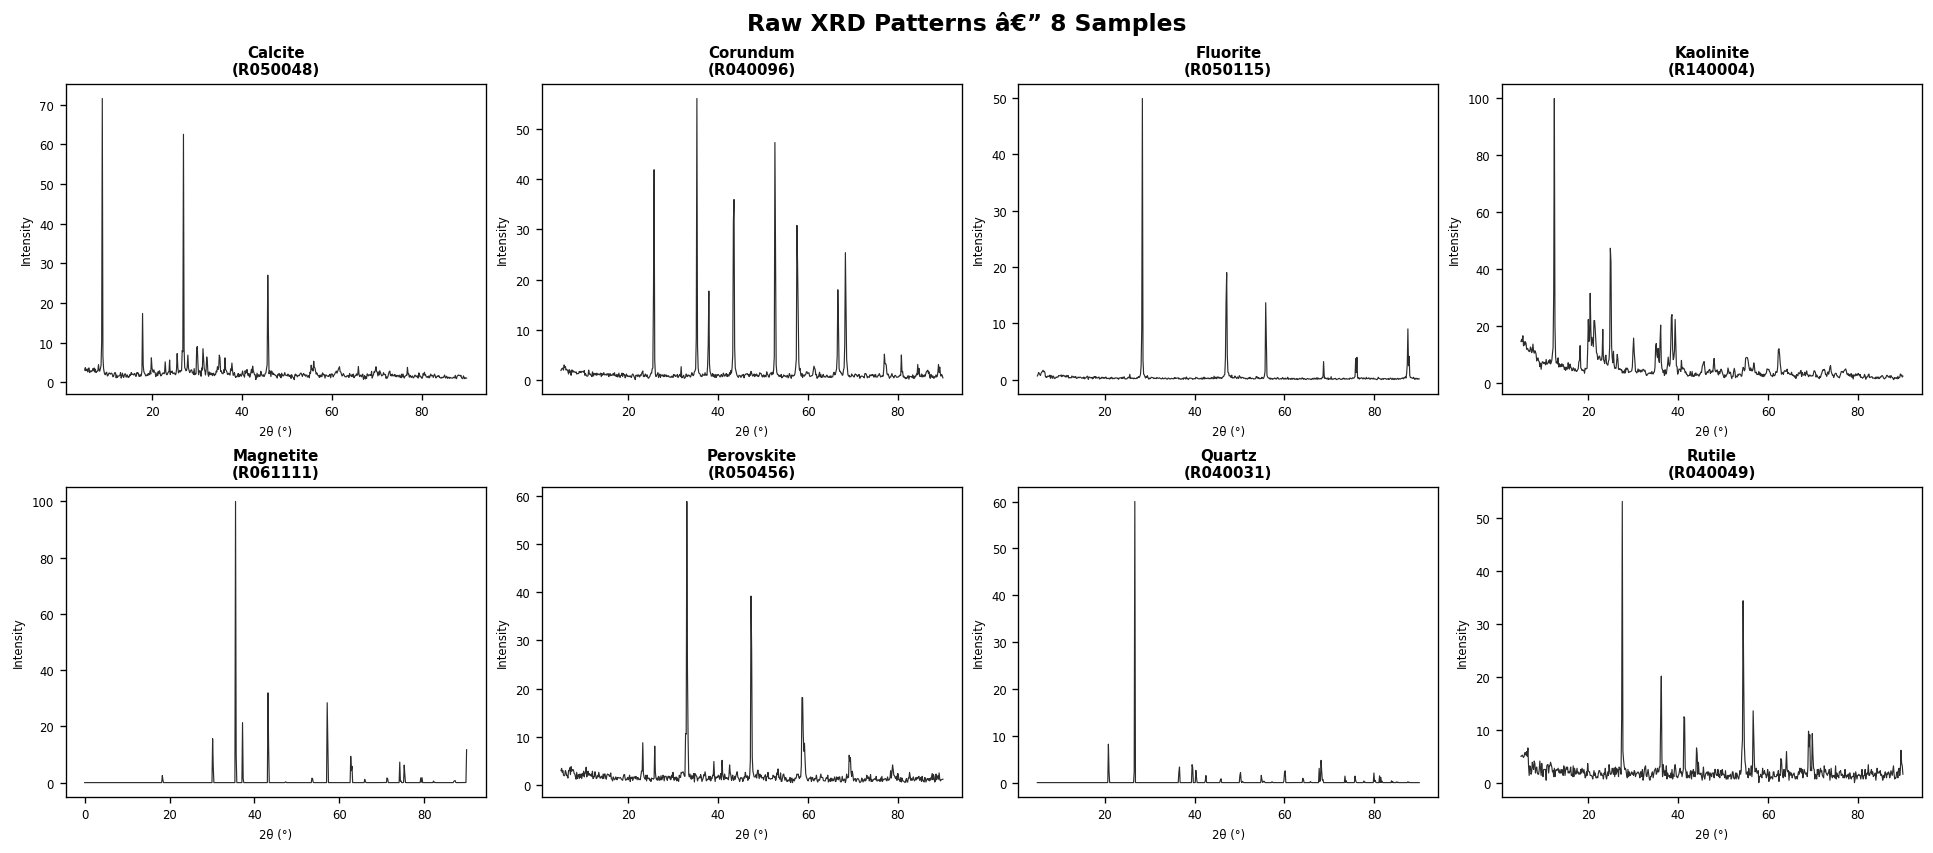

8 raw diffraction patterns loaded. Each shows intensity vs. 2θ scattering angle.


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
fig.suptitle("Raw XRD Patterns â€” 8 Samples", fontsize=14, fontweight="bold")

for ax, (name, xrd) in zip(axes.flat, samples.items()):
    ax.plot(xrd.df["two_theta"], xrd.df["intensity"], color="#2c2c2c", lw=0.7)
    mineral = name.split("__")[0]
    rruff_id = name.split("__")[1] if "__" in name else ""
    ax.set_title(f"{mineral}\n({rruff_id})", fontsize=9, fontweight="bold")
    ax.set_xlabel("2θ (°)", fontsize=7)
    ax.set_ylabel("Intensity", fontsize=7)
    ax.tick_params(labelsize=7)

plt.show()
print("8 raw diffraction patterns loaded. Each shows intensity vs. 2θ scattering angle.")


## Step 3: Single-Sample Fit Walkthrough

Before running the batch, let's walk through the fitting of one sample in detail.
We'll use **Quartz** as the demonstration sample â€” its sharp, well-separated peaks make the fitting steps easy to follow.

The fitting process:
1. **Peak detection**: `scipy.signal.find_peaks` locates candidate peaks by prominence
2. **Model construction**: one `lmfit.PseudoVoigtModel` per peak + flat background (`ConstantModel`)
3. **Optimization**: Levenberg-Marquardt nonlinear least squares
4. **Extraction**: dominant peak â†’ FWHM â†’ Scherrer size


Sample: Quartz__R040031
Detected 2 peaks at 2θ = [20.82, 26.7]


C:\Users\enigm\AppData\Local\Programs\Python\Python313\Lib\site-packages\lmfit\minimizer.py:447: RuntimeWarning: ignoring `maxfev` argument to `Minimizer()`. Use `max_nfev` instead.
  warnings.warn(maxeval_warning.format(maxnfev_alias, 'Minimizer'),


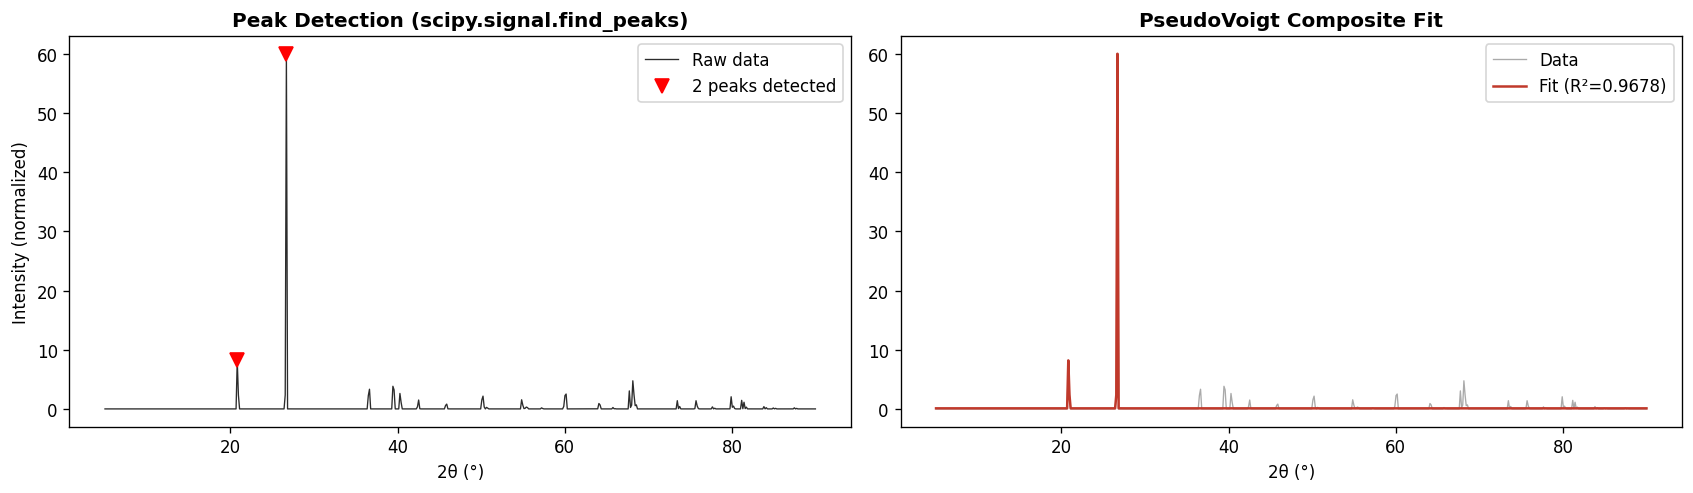


Dominant peak:  2θ = 26.666°  |  FWHM = 0.0922°  |  Î· = 0.000
Fit quality:    R² = 0.9678  |  AIC = -960.0  |  BIC = -920.3
Peaks fitted:   2


In [3]:
from scipy.signal import find_peaks
from lmfit.models import PseudoVoigtModel, ConstantModel

# Select a sample (use Quartz if available, else first sample)
demo_name = next((n for n in samples if "Quartz" in n), list(samples.keys())[0])
demo = samples[demo_name]
x = demo.df["two_theta"].values
y = demo.df["intensity"].values

# Step 1: Peak detection â€” same parameters as the batch fitter
fitter = XRDFitter()  # use default prominence/distance so walkthrough matches batch
dx = float(np.mean(np.diff(x)))
peak_indices, props = find_peaks(y, prominence=fitter.prominence,
                                 distance=max(1, int(fitter.min_distance_deg / dx)))
print(f"Sample: {demo_name}")
print(f"Detected {len(peak_indices)} peaks at 2θ = {x[peak_indices].round(2).tolist()}")

# Visualize detection
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].plot(x, y, color="#2c2c2c", lw=0.8, label="Raw data")
axes[0].plot(x[peak_indices], y[peak_indices], "rv", ms=8, label=f"{len(peak_indices)} peaks detected")
axes[0].set_title("Peak Detection (scipy.signal.find_peaks)", fontweight="bold")
axes[0].set_xlabel("2θ (°)")
axes[0].set_ylabel("Intensity (normalized)")
axes[0].legend()

# Step 2â€“3: Fit
# fitter already created above
result = fitter.fit_sample(demo)

axes[1].plot(x, y, color="#aaa", lw=0.8, label="Data", zorder=1)
axes[1].plot(x, result.lmfit_result.best_fit, color="#c0392b", lw=1.5, label=f"Fit (R²={result.r_squared:.4f})", zorder=2)
axes[1].set_title("PseudoVoigt Composite Fit", fontweight="bold")
axes[1].set_xlabel("2θ (°)")
axes[1].legend()
plt.show()

# Step 4: Results
dp = result.dominant_peak
print(f"\nDominant peak:  2θ = {dp['center']:.3f}°  |  FWHM = {dp['fwhm']:.4f}°  |  Î· = {dp['eta']:.3f}")
print(f"Fit quality:    R² = {result.r_squared:.4f}  |  AIC = {result.aic:.1f}  |  BIC = {result.bic:.1f}")
print(f"Peaks fitted:   {result.n_peaks}")


## Step 4: Batch Fit All 8 Samples

In [4]:
fitter = XRDFitter()

print("Running batch peak fitting...")
t0_fit = time.perf_counter()
fit_results = fitter.fit_batch(samples, progress=True)
fit_time = time.perf_counter() - t0_fit

print(f"\nBatch complete: {len(fit_results)} samples fitted in {fit_time:.1f}s")
print(f"\nPer-sample R² values:")
for name, fr in fit_results.items():
    mineral = name.split("__")[0]
    status = "[!]" if fr.r_squared < 0.95 else "[ok]"
    print(f"  {status} {mineral:<20s}  R²={fr.r_squared:.4f}  N_peaks={fr.n_peaks}")


Running batch peak fitting...


Fitting:   0%|          | 0/8 [00:00<?, ?sample/s]

C:\Users\enigm\AppData\Local\Programs\Python\Python313\Lib\site-packages\lmfit\minimizer.py:447: RuntimeWarning: ignoring `maxfev` argument to `Minimizer()`. Use `max_nfev` instead.
  warnings.warn(maxeval_warning.format(maxnfev_alias, 'Minimizer'),


Fitting:  12%|█▎        | 1/8 [00:00<00:02,  2.96sample/s]

C:\Users\enigm\AppData\Local\Programs\Python\Python313\Lib\site-packages\lmfit\minimizer.py:447: RuntimeWarning: ignoring `maxfev` argument to `Minimizer()`. Use `max_nfev` instead.
  warnings.warn(maxeval_warning.format(maxnfev_alias, 'Minimizer'),


...

Fitting:  88%|████████▊ | 7/8 [01:21<00:11, 12.00s/sample]

C:\Users\enigm\AppData\Local\Programs\Python\Python313\Lib\site-packages\lmfit\minimizer.py:447: RuntimeWarning: ignoring `maxfev` argument to `Minimizer()`. Use `max_nfev` instead.
  warnings.warn(maxeval_warning.format(maxnfev_alias, 'Minimizer'),


Fitting: 100%|██████████| 8/8 [01:30<00:00, 10.95s/sample]

Fitting: 100%|██████████| 8/8 [01:30<00:00, 11.31s/sample]


Batch complete: 8 samples fitted in 90.5s

Per-sample R² values:
  [!] Calcite               R²=0.9399  N_peaks=4
  [ok] Corundum              R²=0.9821  N_peaks=8
  [ok] Fluorite              R²=0.9794  N_peaks=4
  [!] Kaolinite             R²=0.8297  N_peaks=11
  [ok] Magnetite             R²=0.9782  N_peaks=6
  [!] Perovskite            R²=0.9381  N_peaks=4
  [ok] Quartz                R²=0.9678  N_peaks=2
  [!] Rutile                R²=0.8901  N_peaks=6


## Step 5: Build Summary Table

In [5]:
summary = XRDAnalyzer.build_summary_table(fit_results)
summary = XRDAnalyzer.flag_outliers(summary)

print(f"Summary table: {len(summary)} samples Ã— {len(summary.columns)} columns")
print()

# Display with highlighting
styled = (
    summary[["Sample", "Phase", "2θ (°)", "d-spacing (Å)", "FWHM (°)", "Crystallite Size (nm)", "R²", "Flag"]]
    .style
    .apply(
        lambda col: [
            "background-color: #ffc0c0" if (isinstance(v, float) and v < 0.90) else
            "background-color: #ffe0e0" if (isinstance(v, float) and v < 0.95) else ""
            for v in col],
        subset=["R²"]
    )
    .format({"2θ (°)": "{:.3f}", "d-spacing (Å)": "{:.4f}", "FWHM (°)": "{:.4f}",
             "Crystallite Size (nm)": "{:.1f}", "R²": "{:.4f}"})
    .set_caption("XRD Summary â€” dominant peak per sample")
)
display(styled)


Summary table: 8 samples Ã— 12 columns



,Sample,Phase,2θ (°),d-spacing (Å),FWHM (°),Crystallite Size (nm),R²,Flag
0,Calcite__R050048,Calcite,8.898,9.9304,0.0895,89.1,0.9399,Review suggested
1,Corundum__R040096,Corundum,57.560,1.5999,0.1787,50.7,0.9821,
2,Fluorite__R050115,Fluorite,28.342,3.1463,0.0739,110.9,0.9794,
3,Kaolinite__R140004,Kaolinite,12.398,7.1335,0.1446,55.3,0.8297,Poor fit
4,Magnetite__R061111,Magnetite,35.592,2.5203,0.1079,77.3,0.9782,
5,Perovskite__R050456,Perovskite,47.345,1.9185,0.0522,166.1,0.9381,Review suggested
6,Quartz__R040031,Quartz,26.666,3.3402,0.0922,88.6,0.9678,
7,Rutile__R040049,Rutile,54.465,1.6833,0.1583,56.5,0.8901,Poor fit


## Step 6: Anomaly Detection

Two detection methods:
- **Z-score** (specification method): flags when |z| > 2.5. With only 8 samples, this threshold is rarely exceeded.
- **IQR** (supplemental): more reliable at small n. Flags values outside Q1 âˆ’ 1.5·IQR or Q3 + 1.5·IQR.


Z-score flags:  4 sample(s)
IQR flags:      1 sample(s)

Z-score flagged samples:


,Sample,Phase,FWHM (°),Crystallite Size (nm),R²,Flag
0,Calcite__R050048,Calcite,0.0895,89.1,0.9399,Review suggested
3,Kaolinite__R140004,Kaolinite,0.1446,55.3,0.8297,Poor fit
5,Perovskite__R050456,Perovskite,0.0522,166.1,0.9381,Review suggested
7,Rutile__R040049,Rutile,0.1583,56.5,0.8901,Poor fit



IQR supplement flagged samples:


,Sample,Phase,FWHM (°),Crystallite Size (nm),Flag (IQR supplement)
5,Perovskite__R050456,Perovskite,0.0522,166.1,Size outlier (IQR)


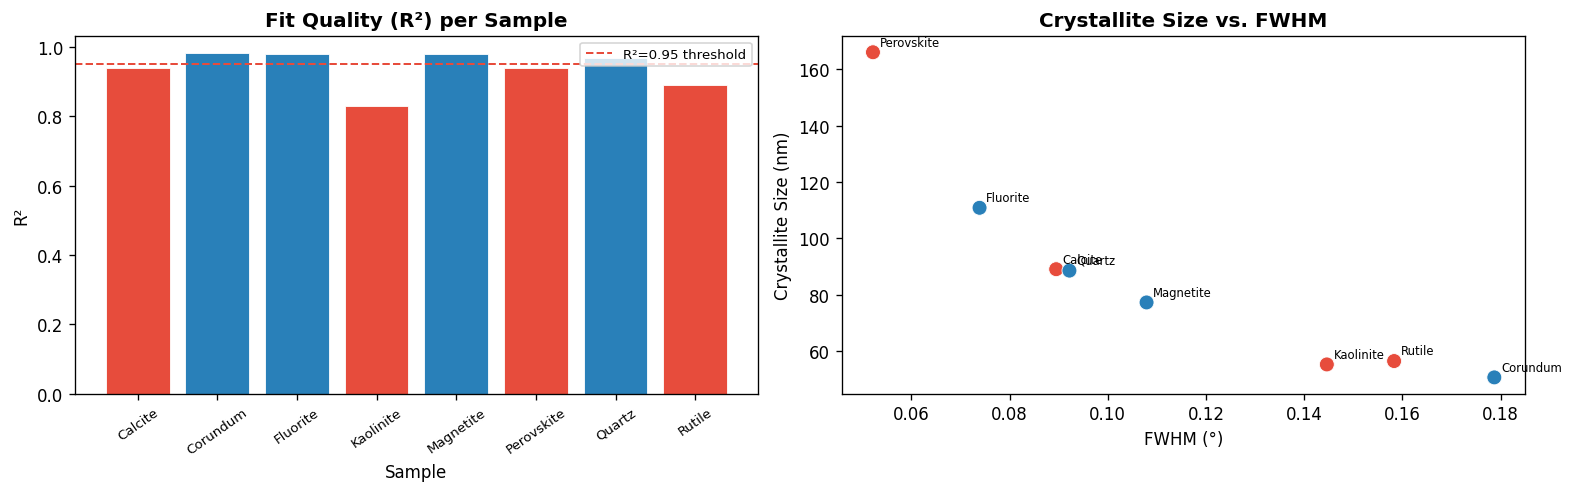

In [6]:
flagged_z = summary[summary["Flag"] != ""]
flagged_iqr = summary[summary["Flag (IQR supplement)"] != ""]

print(f"Z-score flags:  {len(flagged_z)} sample(s)")
print(f"IQR flags:      {len(flagged_iqr)} sample(s)")

if not flagged_z.empty:
    print("\nZ-score flagged samples:")
    display(flagged_z[["Sample", "Phase", "FWHM (°)", "Crystallite Size (nm)", "R²", "Flag"]])

if not flagged_iqr.empty:
    print("\nIQR supplement flagged samples:")
    display(flagged_iqr[["Sample", "Phase", "FWHM (°)", "Crystallite Size (nm)", "Flag (IQR supplement)"]])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

minerals = [n.split("__")[0] for n in summary["Sample"]]
colors = ["#e74c3c" if f else "#2980b9" for f in (summary["Flag"] != "")]

axes[0].bar(minerals, summary["R²"], color=colors, edgecolor="white", linewidth=0.5)
axes[0].axhline(0.95, color="#e74c3c", ls="--", lw=1.2, label="R²=0.95 threshold")
axes[0].set_title("Fit Quality (R²) per Sample", fontweight="bold")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=35, labelsize=8)
axes[0].legend(fontsize=8)

axes[1].scatter(
    summary["FWHM (°)"], summary["Crystallite Size (nm)"],
    c=colors, s=80, edgecolors="white", linewidths=0.5, zorder=3
)
for i, m in enumerate(minerals):
    axes[1].annotate(m, (summary["FWHM (°)"].iloc[i], summary["Crystallite Size (nm)"].iloc[i]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Crystallite Size vs. FWHM", fontweight="bold")
axes[1].set_xlabel("FWHM (°)")
axes[1].set_ylabel("Crystallite Size (nm)")
plt.show()


## Step 7: Generate HTML Technical Memo

In [7]:
reporter = HTMLReporter(template_dir=_repo_root / "templates")

t0_report = time.perf_counter()
memo_html = reporter.render(
    summary_table=summary,
    fit_results=fit_results,
    xrd_data=samples,
    metadata={
        "title": "XRD Batch Analysis â€” Technical Memo",
        "analyst": "Automated Pipeline · Sam Dhole",
        "sample_count": len(samples),
    },
)
report_time = time.perf_counter() - t0_report

output_path = OUTPUT_DIR / "xrd_memo.html"
output_path.write_text(memo_html, encoding="utf-8")

total_time = time.perf_counter() - t0_total

print(f"Memo written to: {output_path}")
print(f"File size: {len(memo_html) / 1024:.0f} KB")
print()
print("=" * 55)
print("  TIMING SUMMARY")
print("=" * 55)
print(f"  Data loading:        {load_time:.2f}s")
print(f"  Batch peak fitting:  {fit_time:.1f}s")
print(f"  HTML report render:  {report_time:.2f}s")
print(f"  Total pipeline time: {total_time:.1f}s")
print()
print(f"  A researcher doing this manually: ~4 hours (14,400s)")
print(f"  This pipeline:                    {total_time:.1f}s")
print(f"  Speedup:                          ~{14400 / total_time:.0f}Ã—")
print("=" * 55)


Memo written to: C:\Users\enigm\sciauto\output\reports\xrd_memo.html
File size: 576 KB

  TIMING SUMMARY
  Data loading:        0.11s
  Batch peak fitting:  90.5s
  HTML report render:  3.09s
  Total pipeline time: 97.6s

  A researcher doing this manually: ~4 hours (14,400s)
  This pipeline:                    97.6s
  Speedup:                          ~148Ã—


---

## Summary

This pipeline demonstrates end-to-end automated XRD characterization:

1. **Data loading** â€” RRUFF-format .txt files parsed with variable-header handling
2. **Peak fitting** â€” Dynamic lmfit PseudoVoigt composite model, auto-detected peak count
3. **Analysis** â€” Scherrer crystallite sizes, d-spacings, dual outlier detection
4. **Reporting** â€” Single-file portable HTML memo with embedded figures and provenance

**The gap this fills:** Every existing XRD tool (SpectraFit, xrdfit, Materials_Data_Analytics) stops at fit parameters. This pipeline goes the last mile â€” from raw data to a formatted deliverable a non-specialist buyer can read.

---
*Generated by XRD Batch Analysis Pipeline · samdhole.github.io*
